# Модель SIR в виде сети Петри: сканирование по β

В этом скрипте проверяется, как результат детерминированной
симуляции зависит от коэффициента заражения $\beta$
при фиксированном $\gamma = 0.1$.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(SIRPetri) || include(srcdir("SIRPetri.jl"))
using .SIRPetri
using DataFrames, CSV, Plots

script_name = "sirpetri_scan_parameters"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab06/project/data"

## Диапазон параметров

In [2]:
β_range = 0.1:0.05:0.8
γ_fixed = 0.1
tmax = 100.0
length(β_range)

15

## Запуск симуляций

Для каждого значения $\beta$ запоминаем максимальное число
инфицированных и конечное число выздоровевших.

In [3]:
results = []
for β in β_range
    net, u0, _ = build_sir_network(β, γ_fixed)
    df = simulate_deterministic(net, u0, (0.0, tmax), saveat = 0.5, rates = [β, γ_fixed])
    peak_I = maximum(df.I)
    final_R = df.R[end]
    push!(results, (β = β, peak_I = peak_I, final_R = final_R))
end

df_scan = DataFrame(results)
CSV.write(datadir("sir_scan.csv"), df_scan)
println(df_scan)

15×3 DataFrame
 Row │ β        peak_I   final_R 
     │ Float64  Float64  Float64 
─────┼───────────────────────────
   1 │    0.1   955.626  999.954
   2 │    0.15  954.157  999.954
   3 │    0.2   953.424  999.954
   4 │    0.25  952.984  999.955
   5 │    0.3   952.691  999.955
   6 │    0.35  952.482  999.955
   7 │    0.4   952.326  999.955
   8 │    0.45  952.204  999.955
   9 │    0.5   952.106  999.955
  10 │    0.55  952.026  999.955
  11 │    0.6   951.96   999.955
  12 │    0.65  951.904  999.955
  13 │    0.7   951.856  999.955
  14 │    0.75  951.814  999.955
  15 │    0.8   951.777  999.955


## График

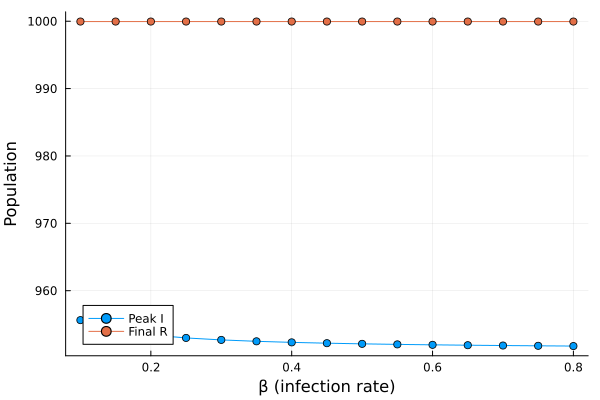

In [4]:
p = plot(
    df_scan.β,
    [df_scan.peak_I df_scan.final_R],
    label = ["Peak I" "Final R"],
    marker = :circle,
    xlabel = "β (infection rate)",
    ylabel = "Population",
)
savefig(p, plotsdir("sir_scan.png"))
p

## Итог

In [5]:
println("Сканирование β завершено. Результат в data/sir_scan.csv")

Сканирование β завершено. Результат в data/sir_scan.csv
